<a href="https://colab.research.google.com/github/niktes03/CS273-Final-Project/blob/main/CS_273_FINAL_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle torchmetrics matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 17.6 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchmetrics import Accuracy, ConfusionMatrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

EMOTION_LABELS = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']


Using device: cuda
GPU: Tesla T4


In [ ]:
 from google.colab import files

print('Upload your kaggle.json file:')
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!kaggle datasets download -d msambare/fer2013 --unzip
print('Dataset downloaded!')

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 174MB/s]

Dataset downloaded!


In [ ]:
# Load from folders. Walks through the train/ and test/ folders, finds every image file, and records its file path + emotion label into a big list.
# Turns that into a pandas DataFrame — essentially a spreadsheet where each row is one image

import os
from PIL import Image

rows = []
for usage, folder in [('Training', 'train'), ('PublicTest', 'test')]:
    for emotion_idx, emotion_name in enumerate(EMOTION_LABELS):
        emotion_folder = os.path.join(folder, emotion_name)
        for img_file in os.listdir(emotion_folder):
            img_path = os.path.join(emotion_folder, img_file)
            rows.append({'path': img_path, 'emotion': emotion_idx, 'Usage': usage})

df = pd.DataFrame(rows)
print(f'Total samples: {len(df)}')
print(df['Usage'].value_counts())

Total samples: 35887
Usage
Training      28709
PublicTest     7178
Name: count, dtype: int64


In [ ]:
# Split into train/val/test
train_df = df[df['Usage'] == 'Training'].reset_index(drop=True)
val_df   = df[df['Usage'] == 'PublicTest'].reset_index(drop=True)
test_df  = df[df['Usage'] == 'PublicTest'].reset_index(drop=True)  # using PublicTest as test too

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

# Compute class weights to handle imbalance
class_counts = np.array([(train_df['emotion'] == i).sum() for i in range(7)])
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * 7
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print(f'\nClass weights:')
for label, w in zip(EMOTION_LABELS, class_weights):
    print(f'  {label}: {w:.4f}')

# since Disgust has way fewer images than Happy, we give the model a higher penalty for getting Disgust wrong during training

Train: 28709 | Val: 7178 | Test: 7178

Class weights:
  angry: 0.4800
  disgust: 4.3982
  fear: 0.4681
  happy: 0.2658
  sad: 0.3970
  surprise: 0.6047
  neutral: 0.3862


In [ ]:
class FER2013Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, int(row['emotion'])

# Tells PyTorch how to load one image from your DataFrame.
# When the training loop asks for image #500, this class opens that image file, converts it to RGB, applies transforms, and returns it with its label.
# PyTorch's DataLoader calls this thousands of times during training.



Data Exploration and Visualization

> Add blockquote



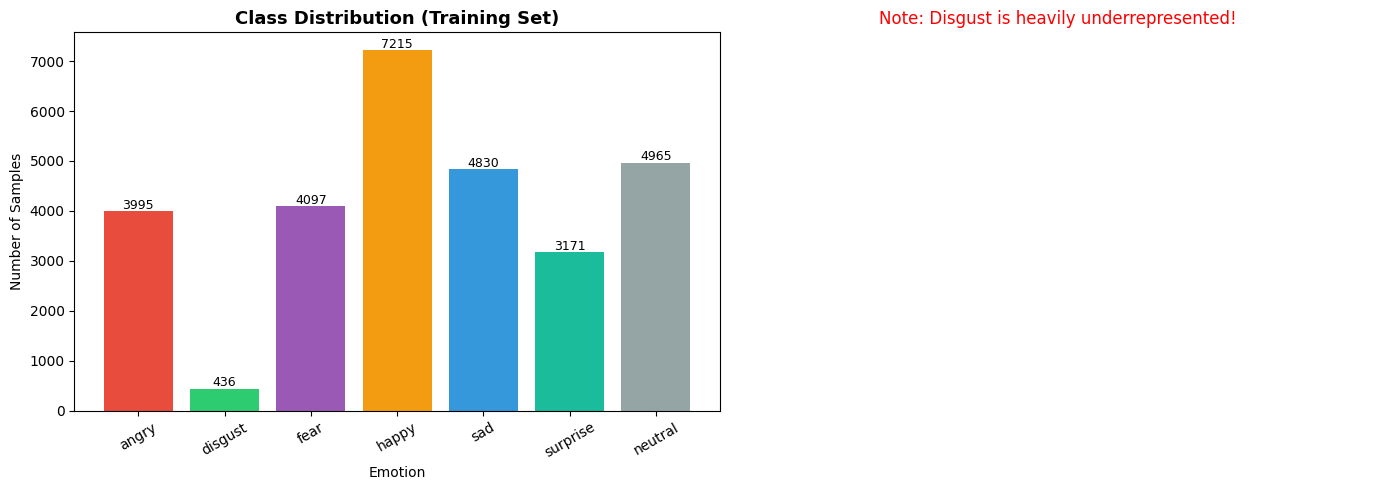

Class imbalance ratio (Happy/Disgust): 16.5x


In [ ]:
# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of class counts (how many images exist per emotion)
counts = [( train_df['emotion'] == i).sum() for i in range(7)]
colors = ['#e74c3c','#2ecc71','#9b59b6','#f39c12','#3498db','#1abc9c','#95a5a6']
axes[0].bar(EMOTION_LABELS, counts, color=colors)
axes[0].set_title('Class Distribution (Training Set)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=9)

# Sample images per emotion
axes[1].axis('off')
axes[1].set_title('Note: Disgust is heavily underrepresented!', fontsize=12, color='red')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Class imbalance ratio (Happy/Disgust): {counts[3]/counts[1]:.1f}x')

# Visually shows the class imbalance problem you're solving.

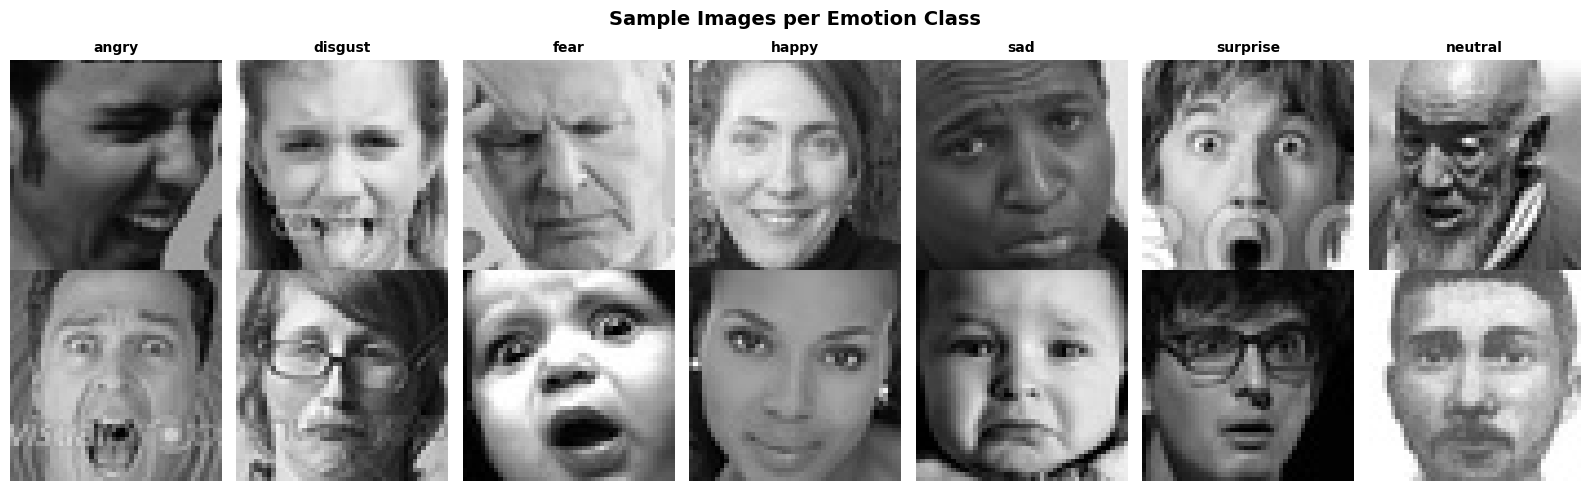

In [ ]:
fig, axes = plt.subplots(2, 7, figsize=(16, 5))
for col, (emotion_idx, label) in enumerate(enumerate(EMOTION_LABELS)):
    samples = train_df[train_df['emotion'] == emotion_idx].sample(2, random_state=SEED)
    for row, (_, sample) in enumerate(samples.iterrows()):
        img = Image.open(sample['path']).convert('RGB')
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(label, fontsize=10, fontweight='bold')
plt.suptitle('Sample Images per Emotion Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Dataset Class & Preprocessing

In [ ]:
class FER2013Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img = Image.open(row['path']).convert('RGB')  # ← this is the key change
        if self.transform:
            img = self.transform(img)
        return img, int(row['emotion'])


# Transforms
BASE_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_train_augmented = transforms.Compose([
    transforms.Resize((BASE_SIZE, BASE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

transform_no_augmentation = transforms.Compose([
    transforms.Resize((BASE_SIZE, BASE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

transform_val = transforms.Compose([
    transforms.Resize((BASE_SIZE, BASE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print('Transforms defined.')

Transforms defined.


In [ ]:
# Split data
train_df = df[df['Usage'] == 'Training'].reset_index(drop=True)
val_df   = df[df['Usage'] == 'PublicTest'].reset_index(drop=True)
test_df  = df[df['Usage'] == 'PrivateTest'].reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

# Compute class weights to handle imbalance
class_counts = np.array([(train_df['emotion'] == i).sum() for i in range(7)])
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * 7  # normalize
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print(f'\nClass weights (for weighted loss):')
for label, w in zip(EMOTION_LABELS, class_weights):
    print(f'  {label}: {w:.4f}')

Train: 28709 | Val: 7178 | Test: 0

Class weights (for weighted loss):
  angry: 0.4800
  disgust: 4.3982
  fear: 0.4681
  happy: 0.2658
  sad: 0.3970
  surprise: 0.6047
  neutral: 0.3862


In [ ]:
from sklearn.model_selection import train_test_split

train_df = df[df['Usage'] == 'Training'].reset_index(drop=True)
public_df = df[df['Usage'] == 'PublicTest'].reset_index(drop=True)
val_df, test_df = train_test_split(public_df, test_size=0.5, random_state=42, stratify=public_df['emotion'])
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

Model Architecture

In [ ]:
def build_model(freeze_backbone=False):
    """
    Build EfficientNet-B0 with a custom classification head.

    Args:
        freeze_backbone (bool): If True, freeze all layers except the head.
                                If False, fine-tune the entire network.
    Returns:
        model (nn.Module)
    """
    model = models.efficientnet_b0(weights='IMAGENET1K_V1')

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace classifier head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, 7)
    )

    return model.to(device)


test_model = build_model(freeze_backbone=False)
dummy_input = torch.randn(2, 3, 224, 224).to(device)
dummy_output = test_model(dummy_input)
print(f'Model output shape: {dummy_output.shape}  ✓  (expected: [2, 7])')

total_params = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
del test_model

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 154MB/s]


Model output shape: torch.Size([2, 7])  ✓  (expected: [2, 7])
Total parameters:     4,337,283
Trainable parameters: 4,337,283


Training and Evaluation Functions

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += imgs.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def run_experiment(name, freeze_backbone, use_augmentation, use_class_weights, num_epochs=15, batch_size=64):
    """
    Run a single training experiment.

    Args:
        name             (str):  Experiment name for logging
        freeze_backbone  (bool): Freeze pretrained layers
        use_augmentation (bool): Apply data augmentation
        use_class_weights(bool): Use weighted cross-entropy loss
        num_epochs       (int):  Number of training epochs
        batch_size       (int):  Batch size

    Returns:
        dict with history and final metrics
    """
    print(f'\n{'='*60}')
    print(f'  Experiment: {name}')
    print(f'  freeze_backbone={freeze_backbone} | augmentation={use_augmentation} | class_weights={use_class_weights}')
    print(f'{'='*60}')

    # Datasets and Loaders
    train_transform = transform_train_augmented if use_augmentation else transform_no_augmentation
    train_dataset = FER2013Dataset(train_df, transform=train_transform)
    val_dataset   = FER2013Dataset(val_df,   transform=transform_val)
    test_dataset  = FER2013Dataset(test_df,  transform=transform_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # Model, Loss, Optimizer
    model = build_model(freeze_backbone=freeze_backbone)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor if use_class_weights else None)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    best_model_state = None

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss,   val_acc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 3 == 0 or epoch == num_epochs:
            print(f'  Epoch {epoch:02d}/{num_epochs} | '
                  f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
                  f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

    # Load best model and evaluate on test set
    model.load_state_dict(best_model_state)
    test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)

    print(f'\n  ✅ Best Val Acc: {best_val_acc:.4f} | Test Acc: {test_acc:.4f}')

    return {
        'name': name,
        'history': history,
        'best_val_acc': best_val_acc,
        'test_acc': test_acc,
        'test_preds': test_preds,
        'test_labels': test_labels,
        'model': model
    }

print('Training functions defined.')

Training functions defined.


Ablation Experiments

In [ ]:
# Run all 4 for the full ablation, or just Experiment 4 for the best result

NUM_EPOCHS = 15

results = {}

results['exp1'] = run_experiment(
    name='1. Baseline (frozen backbone)',
    freeze_backbone=True,
    use_augmentation=False,
    use_class_weights=False,
    num_epochs=NUM_EPOCHS
)


  Experiment: 1. Baseline (frozen backbone)
  freeze_backbone=True | augmentation=False | class_weights=False
  Epoch 03/15 | Train Loss: 1.4477 Acc: 0.4410 | Val Loss: 1.4277 Acc: 0.4492
  Epoch 06/15 | Train Loss: 1.3517 Acc: 0.4792 | Val Loss: 1.3800 Acc: 0.4628
  Epoch 09/15 | Train Loss: 1.2772 Acc: 0.5171 | Val Loss: 1.3787 Acc: 0.4675
  Epoch 12/15 | Train Loss: 1.2206 Acc: 0.5386 | Val Loss: 1.3620 Acc: 0.4770
  Epoch 15/15 | Train Loss: 1.1993 Acc: 0.5478 | Val Loss: 1.3564 Acc: 0.4806

  ✅ Best Val Acc: 0.4837 | Test Acc: 0.5071


In [ ]:
results['exp2'] = run_experiment(
    name='2. Unfrozen backbone',
    freeze_backbone=False,
    use_augmentation=False,
    use_class_weights=False,
    num_epochs=NUM_EPOCHS
)


  Experiment: 2. Unfrozen backbone
  freeze_backbone=False | augmentation=False | class_weights=False
  Epoch 03/15 | Train Loss: 0.8460 Acc: 0.6889 | Val Loss: 0.9897 Acc: 0.6489
  Epoch 06/15 | Train Loss: 0.5070 Acc: 0.8149 | Val Loss: 1.0528 Acc: 0.6643
  Epoch 09/15 | Train Loss: 0.1578 Acc: 0.9445 | Val Loss: 1.5515 Acc: 0.6673
  Epoch 12/15 | Train Loss: 0.0405 Acc: 0.9868 | Val Loss: 2.0216 Acc: 0.6648
  Epoch 15/15 | Train Loss: 0.0166 Acc: 0.9944 | Val Loss: 2.1495 Acc: 0.6712

  ✅ Best Val Acc: 0.6715 | Test Acc: 0.6913


In [ ]:
results['exp3'] = run_experiment(
    name='3. Unfrozen + Augmentation',
    freeze_backbone=False,
    use_augmentation=True,
    use_class_weights=False,
    num_epochs=NUM_EPOCHS
)


  Experiment: 3. Unfrozen + Augmentation
  freeze_backbone=False | augmentation=True | class_weights=False
  Epoch 03/15 | Train Loss: 0.9504 Acc: 0.6450 | Val Loss: 0.9933 Acc: 0.6261
  Epoch 06/15 | Train Loss: 0.7907 Acc: 0.7051 | Val Loss: 0.9091 Acc: 0.6776
  Epoch 09/15 | Train Loss: 0.5944 Acc: 0.7802 | Val Loss: 0.8988 Acc: 0.6932
  Epoch 12/15 | Train Loss: 0.3786 Acc: 0.8611 | Val Loss: 1.0362 Acc: 0.7024
  Epoch 15/15 | Train Loss: 0.2643 Acc: 0.9029 | Val Loss: 1.1477 Acc: 0.6994

  ✅ Best Val Acc: 0.7027 | Test Acc: 0.7189


In [ ]:
results['exp4'] = run_experiment(
    name='4. Full: Unfrozen + Augmentation + Class Weights',
    freeze_backbone=False,
    use_augmentation=True,
    use_class_weights=True,
    num_epochs=NUM_EPOCHS
)


  Experiment: 4. Full: Unfrozen + Augmentation + Class Weights
  freeze_backbone=False | augmentation=True | class_weights=True
  Epoch 03/15 | Train Loss: 1.1057 Acc: 0.5870 | Val Loss: 1.0888 Acc: 0.6018
  Epoch 06/15 | Train Loss: 0.9064 Acc: 0.6533 | Val Loss: 1.0078 Acc: 0.6442
  Epoch 09/15 | Train Loss: 0.7143 Acc: 0.7119 | Val Loss: 0.9725 Acc: 0.6676
  Epoch 12/15 | Train Loss: 0.5562 Acc: 0.7761 | Val Loss: 1.0025 Acc: 0.7021
  Epoch 15/15 | Train Loss: 0.4590 Acc: 0.8151 | Val Loss: 1.0559 Acc: 0.7027

  ✅ Best Val Acc: 0.7030 | Test Acc: 0.7099


Evaluation & Results

In [ ]:
# Summary table
print('\n📊 Ablation Study Results')
print(f'{"Experiment":<45} {"Val Acc":>8} {"Test Acc":>9}')
print('-' * 65)
for key, r in results.items():
    print(f"{r['name']:<45} {r['best_val_acc']:>8.4f} {r['test_acc']:>9.4f}")


📊 Ablation Study Results
Experiment                                     Val Acc  Test Acc
-----------------------------------------------------------------
1. Baseline (frozen backbone)                   0.4837    0.5071
2. Unfrozen backbone                            0.6715    0.6913
3. Unfrozen + Augmentation                      0.7027    0.7189
4. Full: Unfrozen + Augmentation + Class Weights   0.7030    0.7099


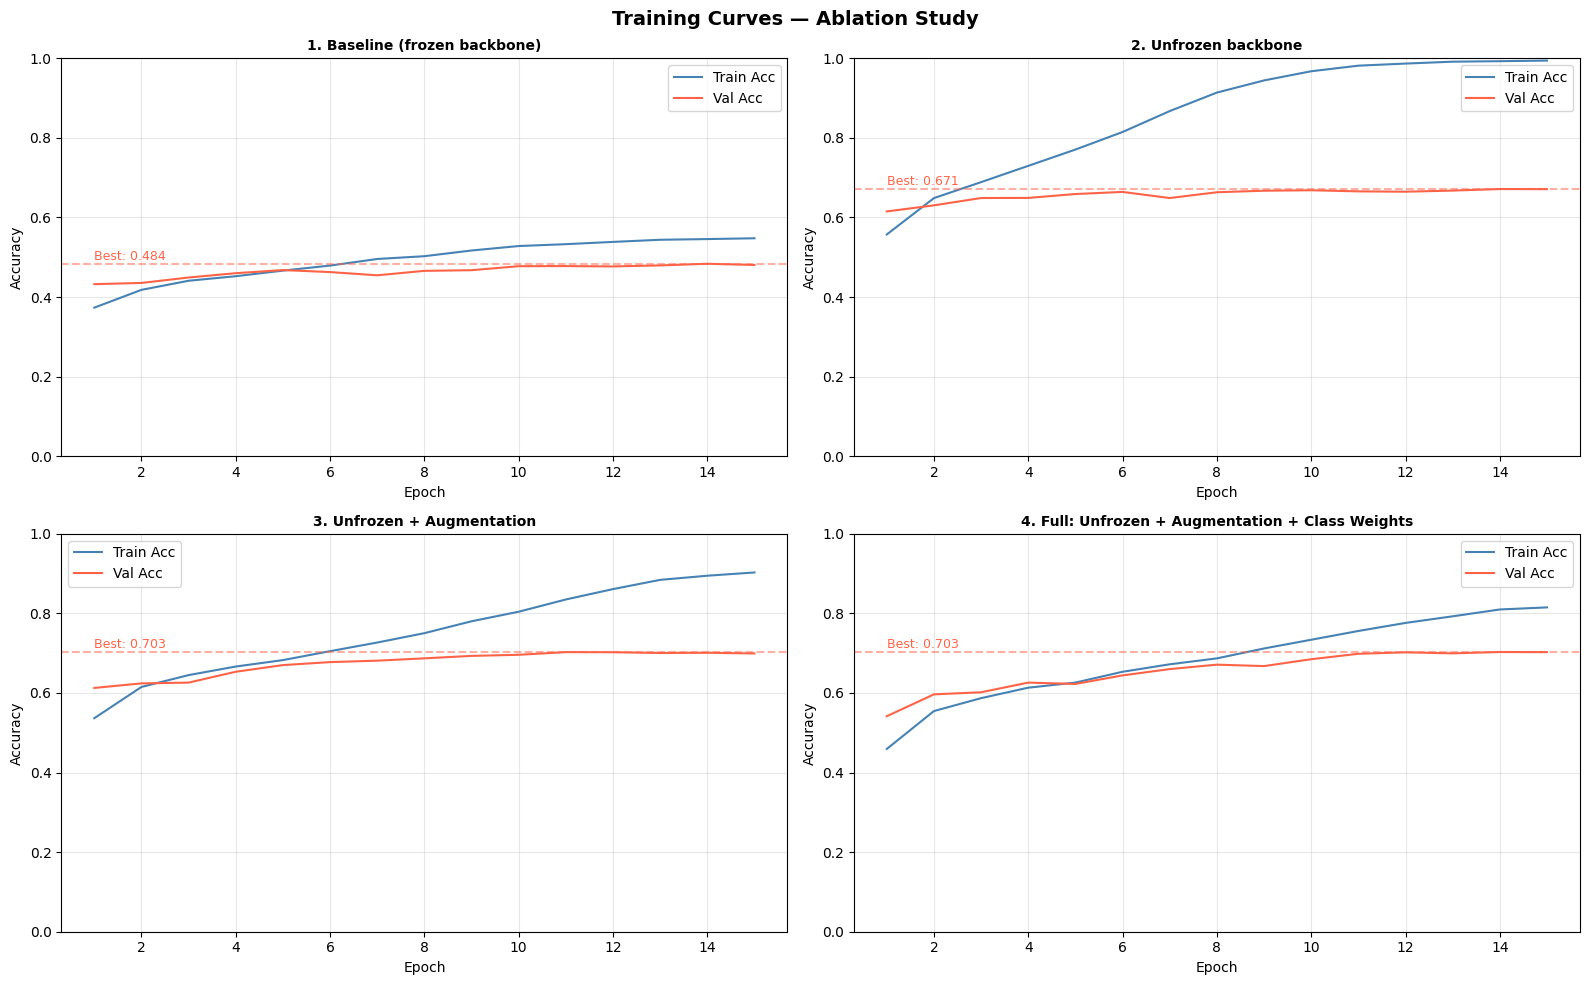

In [ ]:
# Training curves
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (key, r) in zip(axes, results.items()):
    epochs = range(1, len(r['history']['train_acc']) + 1)
    ax.plot(epochs, r['history']['train_acc'], label='Train Acc', color='steelblue')
    ax.plot(epochs, r['history']['val_acc'],   label='Val Acc',   color='tomato')
    ax.set_title(r['name'], fontsize=10, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.axhline(r['best_val_acc'], linestyle='--', color='tomato', alpha=0.5)
    ax.text(1, r['best_val_acc'] + 0.01, f"Best: {r['best_val_acc']:.3f}", color='tomato', fontsize=9)

plt.suptitle('Training Curves — Ablation Study', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

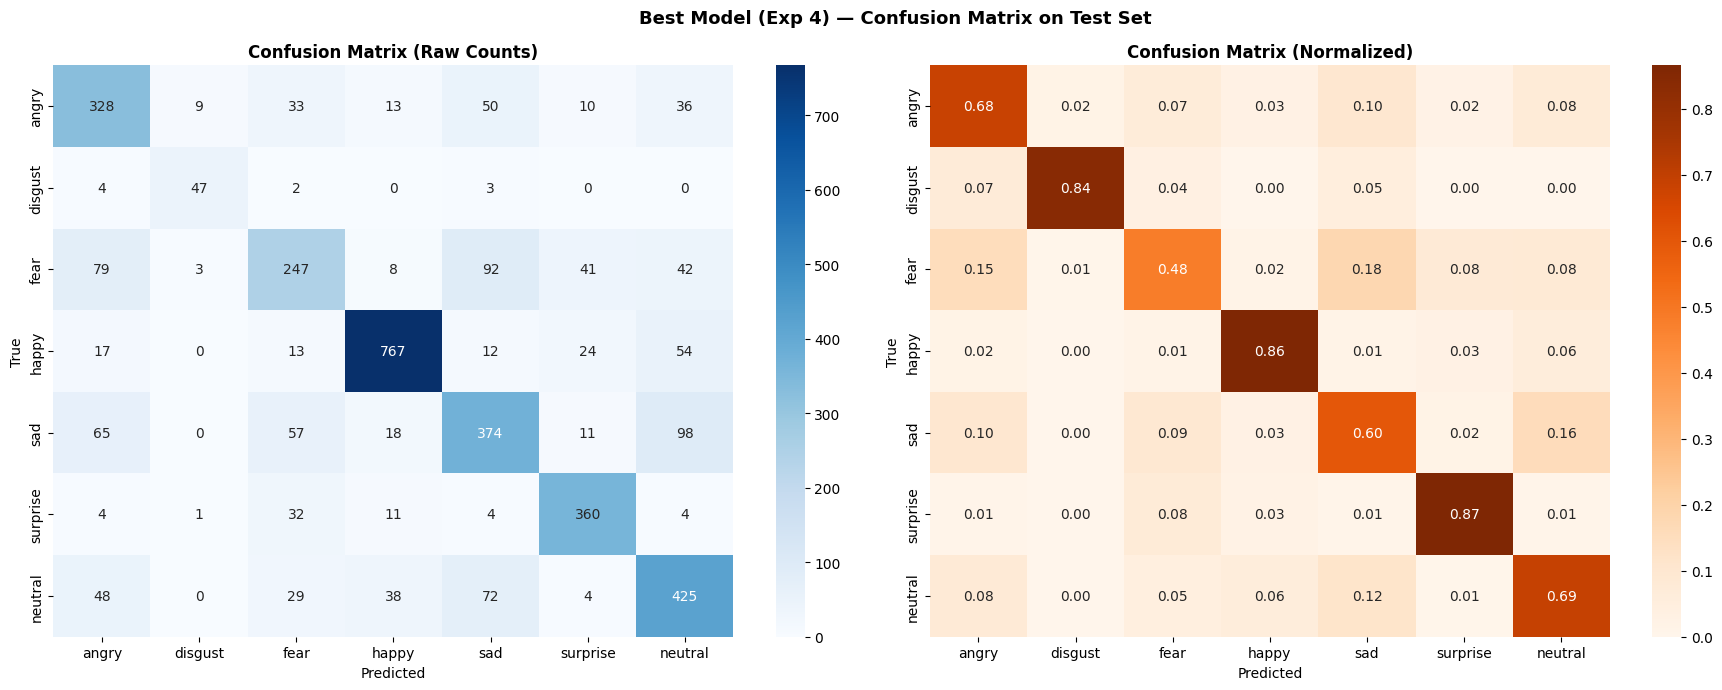


📋 Classification Report:
              precision    recall  f1-score   support

       angry       0.60      0.68      0.64       479
     disgust       0.78      0.84      0.81        56
        fear       0.60      0.48      0.53       512
       happy       0.90      0.86      0.88       887
         sad       0.62      0.60      0.61       623
    surprise       0.80      0.87      0.83       416
     neutral       0.64      0.69      0.67       616

    accuracy                           0.71      3589
   macro avg       0.71      0.72      0.71      3589
weighted avg       0.71      0.71      0.71      3589



In [ ]:
best_result = results['exp4']
preds  = best_result['test_preds']
labels = best_result['test_labels']

from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(labels, preds)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS, ax=axes[0])
axes[0].set_title('Confusion Matrix (Raw Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.suptitle('Best Model (Exp 4) — Confusion Matrix on Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📋 Classification Report:')
print(classification_report(labels, preds, target_names=EMOTION_LABELS))

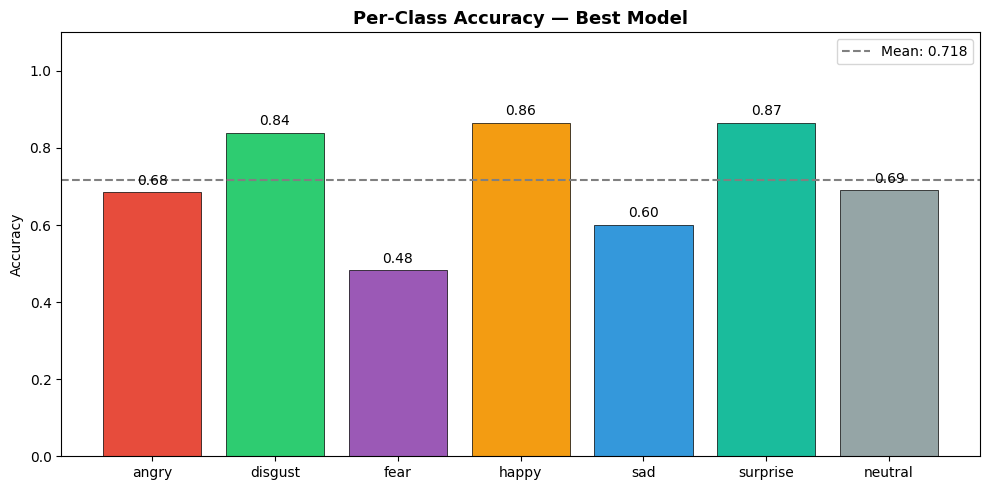

In [ ]:
per_class_acc = cm_normalized.diagonal()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(EMOTION_LABELS, per_class_acc, color=colors, edgecolor='black', linewidth=0.5)
ax.set_title('Per-Class Accuracy — Best Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
ax.axhline(per_class_acc.mean(), linestyle='--', color='gray', label=f'Mean: {per_class_acc.mean():.3f}')
ax.legend()
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.02, f'{acc:.2f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
torch.save(best_result['model'].state_dict(), 'best_model.pth')
print('Best model saved to best_model.pth')

Best model saved to best_model.pth
